In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
data = pd.read_csv('titanic/train.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
data['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [4]:
datac = data.copy()

In [5]:
datac.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
datac.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
datac.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [8]:
datac.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
datac[['Embarked']].value_counts()

Embarked
S           644
C           168
Q            77
Name: count, dtype: int64

In [10]:
datac.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [11]:
x_train = datac.drop('Survived', axis=1)
y_train = datac['Survived']

In [12]:
# pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')), 
#                  ('encode', OrdinalEncoder())])

pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')), 
                 ('encode', OneHotEncoder())])

In [13]:
column_cleaning = ColumnTransformer([('impute_encode', pipe, ['Sex', 'Embarked']),
                         ('impute_age', SimpleImputer(strategy='mean'), ['Age'])],
                        remainder='passthrough')

In [14]:
preprocessing = Pipeline([('encode', column_cleaning), 
                          ('scale', MinMaxScaler(feature_range=(0,1)))])

# preprocessing = Pipeline([('encode', column_cleaning), 
#                           ('scale', StandardScaler())])

In [15]:
pipeline1 = Pipeline([('preprocessing', preprocessing), ('model', SGDClassifier(random_state=42, n_jobs=-1))])

In [16]:
cross_val_score(pipeline1, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1, )

array([0.74410774, 0.7979798 , 0.78451178])

In [17]:
y_train_pred = cross_val_predict(pipeline1, x_train, y_train, cv=3, n_jobs=-1, )

In [18]:
confusion_matrix(y_train, y_train_pred)

array([[512,  37],
       [163, 179]])

In [19]:
# f1_score(y_train, y_train_pred)
accuracy_SGDC = accuracy_score(y_train, y_train_pred)
accuracy_SGDC

0.7755331088664422

In [20]:
pipeline2 = Pipeline([('preprocessing', preprocessing), ('model', SVC(gamma='auto', random_state=42))])

In [21]:
cross_val_score(pipeline2, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1, )

array([0.78787879, 0.8013468 , 0.77104377])

In [22]:
y_train_pred = cross_val_predict(pipeline2, x_train, y_train, cv=3, n_jobs=-1, )

In [23]:
confusion_matrix(y_train, y_train_pred)

array([[468,  81],
       [109, 233]])

In [24]:
# f1_score(y_train, y_train_pred)
accuracy_SVC = accuracy_score(y_train, y_train_pred)
accuracy_SVC

0.7867564534231201

In [25]:
pipeline3 = Pipeline([('preprocessing', preprocessing), ('model', RandomForestClassifier(n_estimators = 500, max_depth =10, random_state=42))])

In [26]:
cross_val_score(pipeline3, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1, )

array([0.78787879, 0.83838384, 0.82828283])

In [27]:
y_train_pred = cross_val_predict(pipeline3, x_train, y_train, cv=3, n_jobs=-1, )

In [28]:
confusion_matrix(y_train, y_train_pred)

array([[485,  64],
       [ 98, 244]])

In [29]:
# f1_score(y_train, y_train_pred)
accuracy_RFC = accuracy_score(y_train, y_train_pred)
accuracy_RFC

0.8181818181818182

In [30]:
pipeline4 = Pipeline([('preprocessing', preprocessing), ('model', DecisionTreeClassifier(random_state=42))])

In [31]:
cross_val_score(pipeline4, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1, )

array([0.74074074, 0.7979798 , 0.76094276])

In [32]:
y_train_pred = cross_val_predict(pipeline4, x_train, y_train, cv=3, n_jobs=-1, )

In [33]:
confusion_matrix(y_train, y_train_pred)

array([[451,  98],
       [110, 232]])

In [34]:
# f1_score(y_train, y_train_pred)
accuracy_DTC = accuracy_score(y_train, y_train_pred)
accuracy_DTC

0.7665544332210998

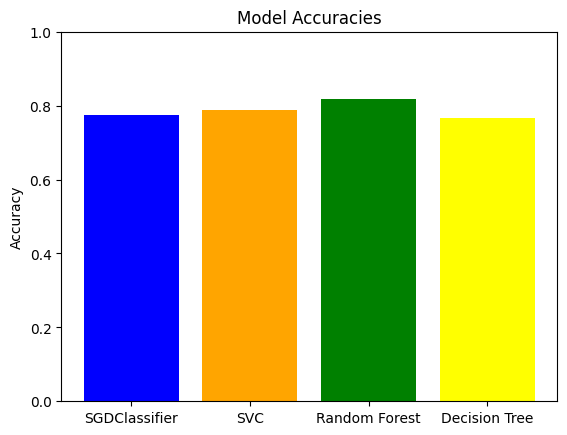

In [39]:
models = ['SGDClassifier', 'SVC', 'Random Forest', 'Decision Tree']
accuracies = [accuracy_SGDC, accuracy_SVC, accuracy_RFC, accuracy_DTC]

plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'yellow'])
plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.ylim([0, 1])
plt.show()